In [1]:
import pandas as pd, numpy as np
from sqlalchemy import create_engine
engine = create_engine("postgresql+psycopg2://postgres@127.0.0.1:5432/trading")

px = pd.read_sql("SELECT date, adj_close FROM prices WHERE ticker='SPY' ORDER BY date",
                 engine, parse_dates=["date"], index_col="date")["adj_close"].astype(float)

In [2]:
def backtest(px, fast, slow, cost_rate=0.0005):
    ema_f = px.ewm(span=fast, adjust=False).mean()
    ema_s = px.ewm(span=slow, adjust=False).mean()
    signal = (ema_f > ema_s).astype(int)
    signal.iloc[:slow] = 0
    position = signal.shift(1).fillna(0)
    ret = px.pct_change().fillna(0)
    trades = position.diff().abs().fillna(0)
    return position * ret - trades * cost_rate

In [3]:
train = px[:"2019-12-31"]
fasts = [10, 20, 30, 50, 75, 100]
slows = [100, 150, 200, 250, 300]

rows = []
for f in fasts:
    for s in slows:
        if f >= s:
            continue
        r = backtest(train, f, s)[train.index[s]:]
        sharpe = r.mean() / r.std() * np.sqrt(252)
        rows.append({"fast": f, "slow": s, "sharpe": sharpe})

grid = pd.DataFrame(rows)
grid.sort_values("sharpe", ascending=False).head(10)

,fast,slow,sharpe
20,75,100,0.790647
15,50,100,0.760093
16,50,150,0.753400
28,100,300,0.734271
27,100,250,0.715090
21,75,150,0.714143
4,10,300,0.701906
0,10,100,0.701674
12,30,200,0.701601
17,50,200,0.701264


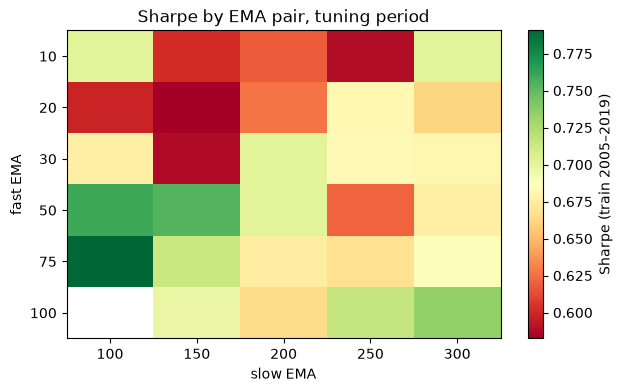

In [4]:
import matplotlib.pyplot as plt
heat = grid.pivot(index="fast", columns="slow", values="sharpe")
plt.figure(figsize=(7, 4))
plt.imshow(heat, cmap="RdYlGn", aspect="auto")
plt.colorbar(label="Sharpe (train 2005–2019)")
plt.xticks(range(len(heat.columns)), heat.columns)
plt.yticks(range(len(heat.index)), heat.index)
plt.xlabel("slow EMA"); plt.ylabel("fast EMA")
plt.title("Sharpe by EMA pair, tuning period");

In [5]:
def best_pair(px_slice):
    best, best_sh = None, -np.inf
    for f in fasts:
        for s in slows:
            if f >= s or len(px_slice) <= s + 252:
                continue
            r = backtest(px_slice, f, s)[px_slice.index[s]:]
            sh = r.mean() / r.std() * np.sqrt(252)
            if sh > best_sh:
                best, best_sh = (f, s), sh
    return best

wf_rets, picks = [], []
for year in range(2010, 2020):
    hist = train[:f"{year-1}-12-31"]
    f, s = best_pair(hist)
    r = backtest(train[:f"{year}-12-31"], f, s)[f"{year}-01-01":]
    wf_rets.append(r)
    picks.append({"year": year, "fast": f, "slow": s})

wf = pd.concat(wf_rets)
print(pd.DataFrame(picks))
print("walk-forward Sharpe 2010–2019:", round(wf.mean() / wf.std() * np.sqrt(252), 3))

   year  fast  slow
0  2010    50   150
1  2011    50   100
2  2012    75   100
3  2013    75   100
4  2014    75   100
5  2015    75   100
6  2016    75   100
7  2017    75   100
8  2018    75   100
9  2019    75   100
walk-forward Sharpe 2010–2019: 0.734


In [6]:
win = slice("2010-01-01", "2019-12-31")
def sh(r): return round(r.mean() / r.std() * np.sqrt(252), 3)

base_5020 = backtest(train, 50, 200)[win]
bh = train.pct_change()[win]
print("buy-and-hold 2010–2019:", sh(bh))
print("fixed 50/200 2010–2019:", sh(base_5020))
print("walk-forward 2010–2019:", sh(wf))

buy-and-hold 2010–2019: 0.933
fixed 50/200 2010–2019: 0.689
walk-forward 2010–2019: 0.734


In [7]:
TUNED_FAST, TUNED_SLOW = 75, 100
TRAIN_END = "2019-12-31"
TEST_START = "2020-01-01"   # not used until the final test

In [8]:
from sqlalchemy import text
with engine.begin() as conn:
    conn.execute(text("""
        CREATE TABLE IF NOT EXISTS backtest_runs (
            run_id      SERIAL PRIMARY KEY,
            strategy_id TEXT, params JSONB,
            train_start DATE, train_end DATE,
            test_start  DATE, test_end  DATE,
            cagr NUMERIC, sharpe NUMERIC, max_dd NUMERIC, n_trades INT,
            created_at  TIMESTAMP DEFAULT now()
        )
    """))

In [9]:
import json
runs = [
    ("ema_fixed",   {"fast": 50, "slow": 200}, "2005-01-01", TRAIN_END, "2010-01-01", TRAIN_END, 0.689),
    ("ema_walkfwd", {"refit": "yearly"},        "2005-01-01", TRAIN_END, "2010-01-01", TRAIN_END, 0.734),
    ("ema_tuned",   {"fast": TUNED_FAST, "slow": TUNED_SLOW, "status": "locked"},
                    "2005-01-01", TRAIN_END, None, None, 0.791),
]
with engine.begin() as conn:
    for sid, p, trs, tre, tes, tee, sh in runs:
        conn.execute(text("""
            INSERT INTO backtest_runs (strategy_id, params, train_start, train_end, test_start, test_end, sharpe)
            VALUES (:sid, CAST(:p AS JSONB), :trs, :tre, :tes, :tee, :sh)
        """), {"sid": sid, "p": json.dumps(p), "trs": trs, "tre": tre, "tes": tes, "tee": tee, "sh": sh})

pd.read_sql("SELECT run_id, strategy_id, params, sharpe FROM backtest_runs", engine)

,run_id,strategy_id,params,sharpe
0,1,ema_fixed,"{'fast': 50, 'slow': 200}",0.689
1,2,ema_walkfwd,{'refit': 'yearly'},0.734
2,3,ema_tuned,"{'fast': 75, 'slow': 100, 'status': 'locked'}",0.791
